# Calculating \\(\pi \\) using a Monte Carlo algorithm

- Börge Göbel

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.patches as patches

(-1.1, 1.1)

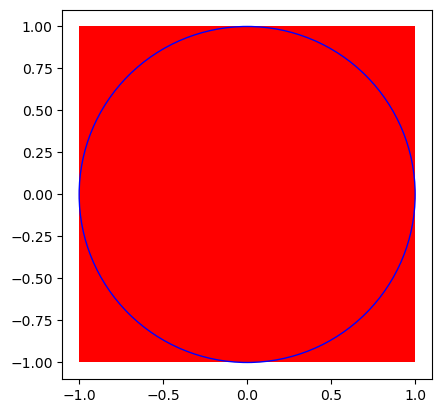

In [2]:
fig = plt.figure()
ax = fig.add_subplot(111, aspect='equal')

rectangle = patches.Rectangle((-1,-1),2,2, facecolor='red')
ax.add_patch(rectangle)

circle = patches.Circle((0,0),1, facecolor='none', edgecolor='blue')
ax.add_patch(circle)

plt.xlim([-1.1,1.1])
plt.ylim([-1.1,1.1])

## Comparing the areas

Area of the circle: \\( A_\mathrm{circle} = \pi r^2 = \pi\\)

Area of the square: \\( A_\mathrm{square} = a^2 = 4 \\)

This means \\( \pi = 4\frac{A_\mathrm{circle}}{A_\mathrm{square}}\\). We can use this ratio to estimate the value of \\( \pi \\). 

### Measure the area ratio by counting randomly generated points

In [3]:
points = 100000

rand = 2*np.random.rand( 2*points) - 1

In [4]:
randpoints = rand.reshape(points, 2)

In [5]:
randpoints[0]

array([-0.22887233, -0.15188761])

In [6]:
normpoints = randpoints[:, 0] ** 2 + randpoints[:, 1] ** 2
# if square of the norm is less than one, then the point is inside the circle.
# if square of the norm is greater than one, then the point is inside the circle.

In [7]:
pointsOut = randpoints[normpoints > 1]
pointsIn = randpoints[normpoints <= 1]

In [8]:
piapprox = 4 * len(pointsIn) / points
print(piapprox)

3.1484


In [9]:
piapprox - np.pi

0.006807346410206971

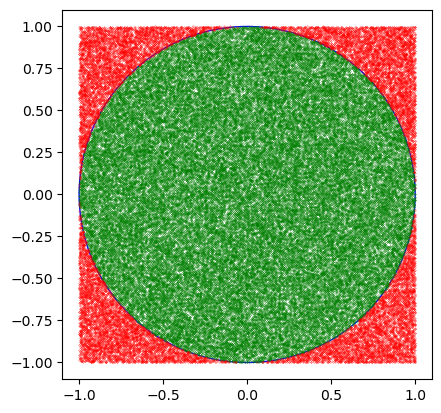

In [10]:
fig = plt.figure()
ax = fig.add_subplot(111, aspect='equal')

#rectangle = patches.Rectangle((-1,-1),2,2, facecolor='red')
#ax.add_patch(rectangle)

circle = patches.Circle((0,0),1, facecolor='none', edgecolor='blue')
ax.add_patch(circle)

plt.xlim([-1.1,1.1])
plt.ylim([-1.1,1.1])

plt.scatter(pointsIn[:, 0], pointsIn[:, 1], color = 'green', s = 0.05)
plt.scatter(pointsOut[:, 0], pointsOut[:, 1], color = 'red', s = 0.05)

### Alternative: Loop method

In [11]:
i = 0
counter = 0

while i < points:
    if np.linalg.norm( 2*np.random.rand(2) - 1 ) < 1:
        counter = counter + 1
    i = i + 1

In [12]:
piapprox = 4 * counter / points
print(piapprox)

3.14572


In [13]:
piapprox - np.pi

0.004127346410206734

### Time comparison

Array/List method

In [16]:
%%timeit

rand = 2*np.random.rand( 2*points) - 1
randpoints = rand.reshape(points, 2)
normpoints = randpoints[:, 0] ** 2 + randpoints[:, 1] ** 2
pointsIn = randpoints[normpoints < 1]
piapprox = 4 * len(pointsIn) / points

2.59 ms ± 151 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Loop method

In [17]:
%%timeit

i = 0
counter = 0

while i < points:
    if np.linalg.norm( 2*np.random.rand(2) - 1 ) < 1:
        counter = counter + 1
    i = i + 1

piapprox = 4 * counter / points

398 ms ± 30.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
